<div style="background: #d9004c; 
            padding: 25px; 
            border-radius: 15px; 
            text-align: center;
            box-shadow: 3px 3px 15px rgba(0,0,0,0.2);">
    <h1 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Digital Image Processing
    </h1>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Topic: Image Sharpening Techniques
    </h3>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Notebook by - Himel Sarder
    </h3>
    <p style="font-family: 'Verdana', sans-serif; color: #ffffffcc; font-size: 16px; text-align: center">
        info.himelcse@gmail.com
    </p>
</div>

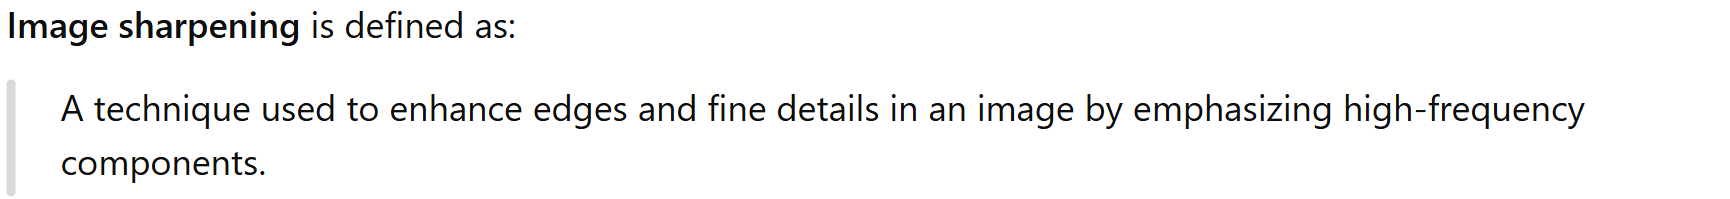
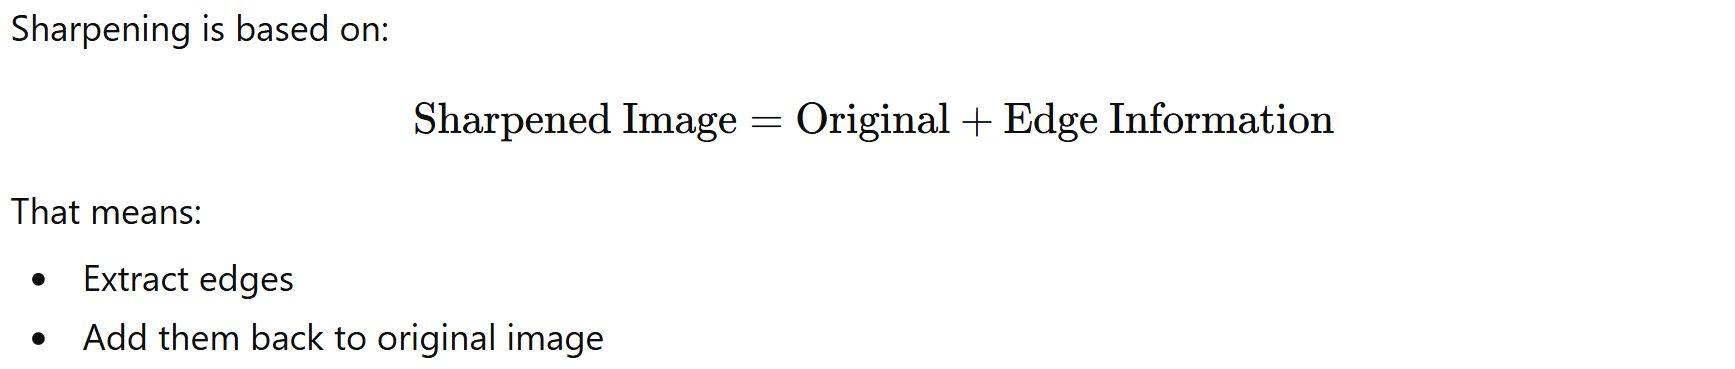


# Kernel-Based Sharpening
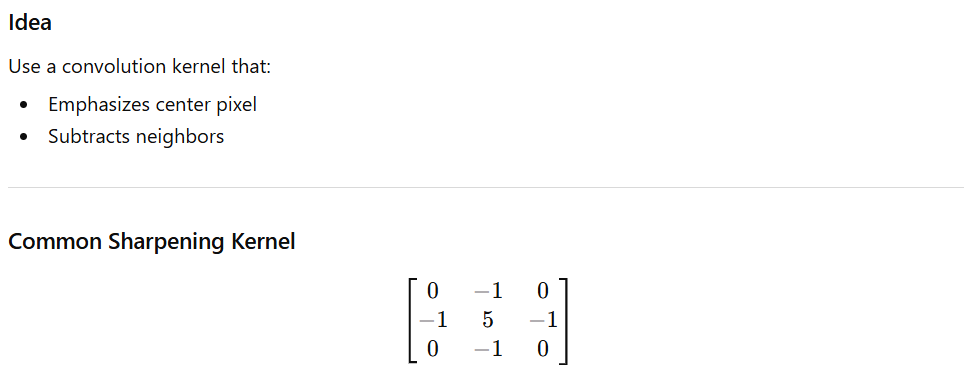

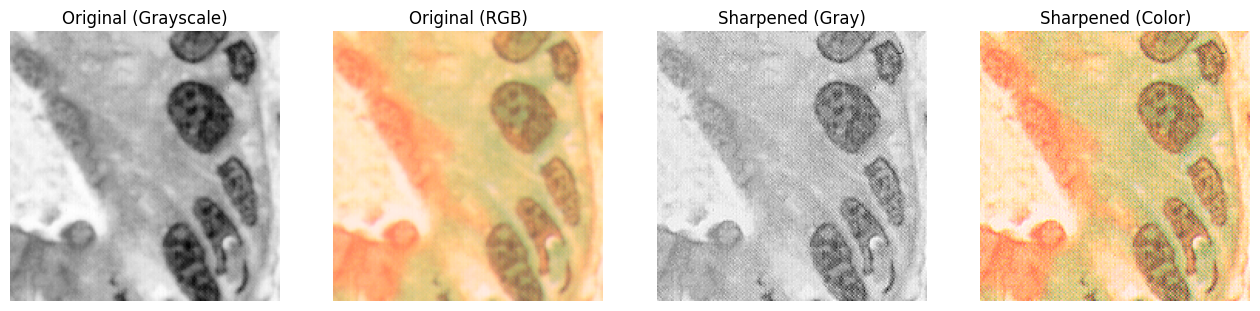

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
gray = cv2.imread('mostBlur.png', cv2.IMREAD_GRAYSCALE)

color = cv2.imread('mostBlur.png')  # BGR
rgb = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)

# Sharpen kernel
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

# Apply sharpening
sharpened_gray = cv2.filter2D(gray, -1, kernel)
sharpened_color = cv2.filter2D(rgb, -1, kernel)

# Plot
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title('Original (Grayscale)')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(rgb)
plt.title('Original (RGB)')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(sharpened_gray, cmap='gray')
plt.title('Sharpened (Gray)')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(sharpened_color)
plt.title('Sharpened (Color)')
plt.axis('off')

plt.show()

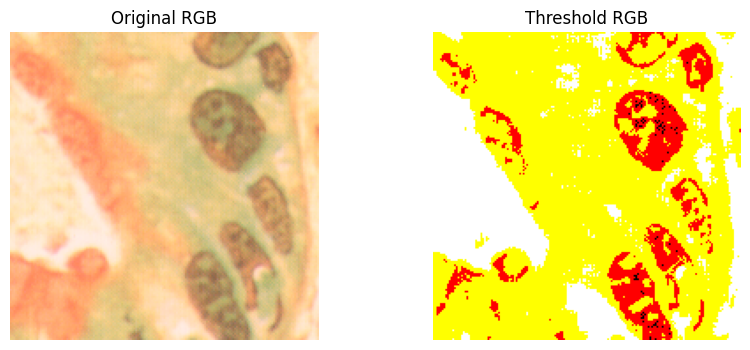

In [12]:
# Load image
color = cv2.imread('mostBlur.png')
rgb = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)

# Split channels
R, G, B = cv2.split(rgb)

# Apply threshold on each channel
_, R_t = cv2.threshold(R, 150, 255, cv2.THRESH_BINARY)
_, G_t = cv2.threshold(G, 150, 255, cv2.THRESH_BINARY)
_, B_t = cv2.threshold(B, 150, 255, cv2.THRESH_BINARY)

# Merge back
threshold_rgb = cv2.merge([R_t, G_t, B_t])

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(threshold_rgb)
plt.title('Threshold RGB')
plt.axis('off')

plt.show()

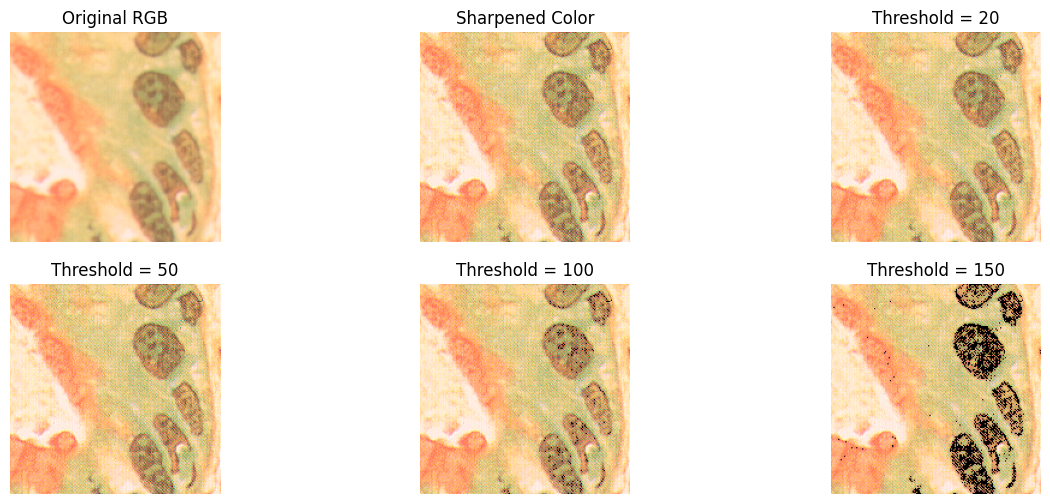

In [14]:
gray = cv2.imread('mostBlur.png', cv2.IMREAD_GRAYSCALE)

color = cv2.imread('mostBlur.png')  # BGR
rgb = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)

# Sharpen kernel
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

# Apply sharpening
sharpened_gray = cv2.filter2D(gray, -1, kernel)
sharpened_color = cv2.filter2D(rgb, -1, kernel)

# Threshold tuning on grayscale
_, mask1 = cv2.threshold(sharpened_gray, 20, 255, cv2.THRESH_BINARY)
_, mask2 = cv2.threshold(sharpened_gray, 50, 255, cv2.THRESH_BINARY)
_, mask3 = cv2.threshold(sharpened_gray, 100, 255, cv2.THRESH_BINARY)
_, mask4 = cv2.threshold(sharpened_gray, 150, 255, cv2.THRESH_BINARY)

# Apply mask on color image
result1 = cv2.bitwise_and(sharpened_color, sharpened_color, mask=mask1)
result2 = cv2.bitwise_and(sharpened_color, sharpened_color, mask=mask2)
result3 = cv2.bitwise_and(sharpened_color, sharpened_color, mask=mask3)
result4 = cv2.bitwise_and(sharpened_color, sharpened_color, mask=mask4)

# Plot
plt.figure(figsize=(15,6))

plt.subplot(2,3,1)
plt.imshow(rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(sharpened_color)
plt.title('Sharpened Color')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(result1)
plt.title('Threshold = 20')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(result2)
plt.title('Threshold = 50')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(result3)
plt.title('Threshold = 100')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(result4)
plt.title('Threshold = 150')
plt.axis('off')

plt.show()

# Laplacian Sharpening
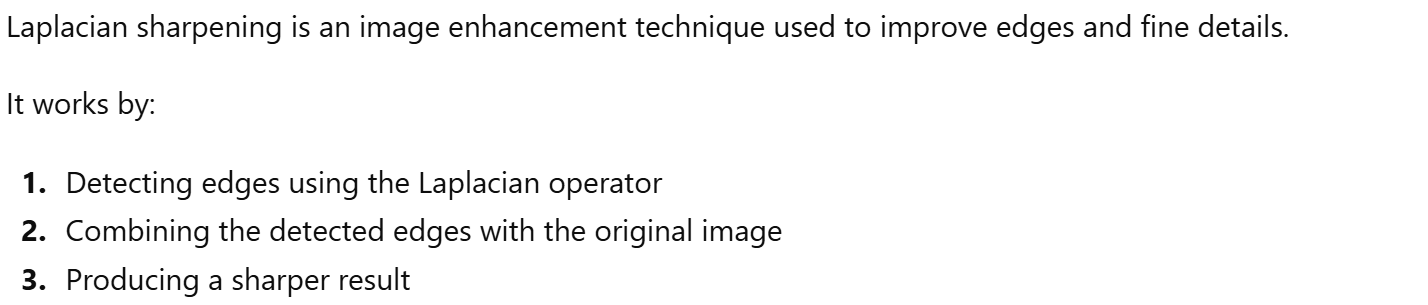
# Mathematical Foundation 
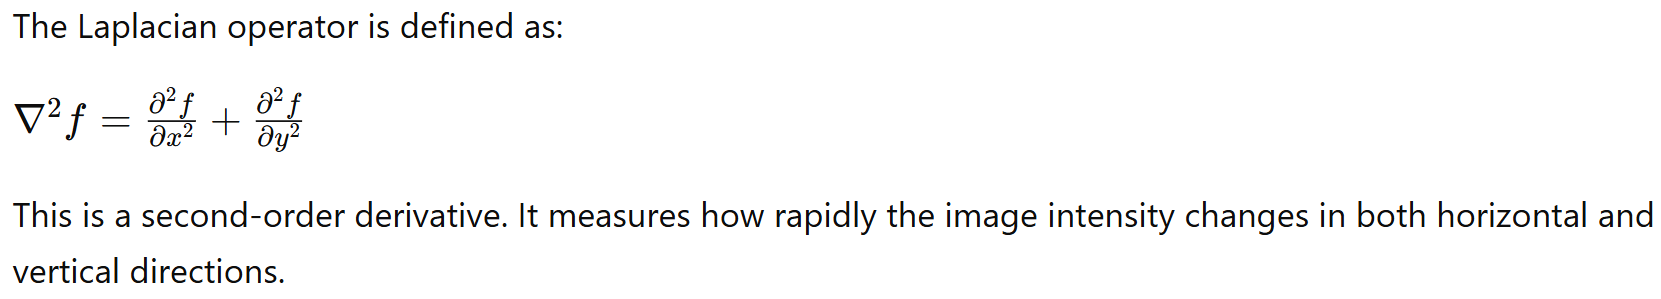
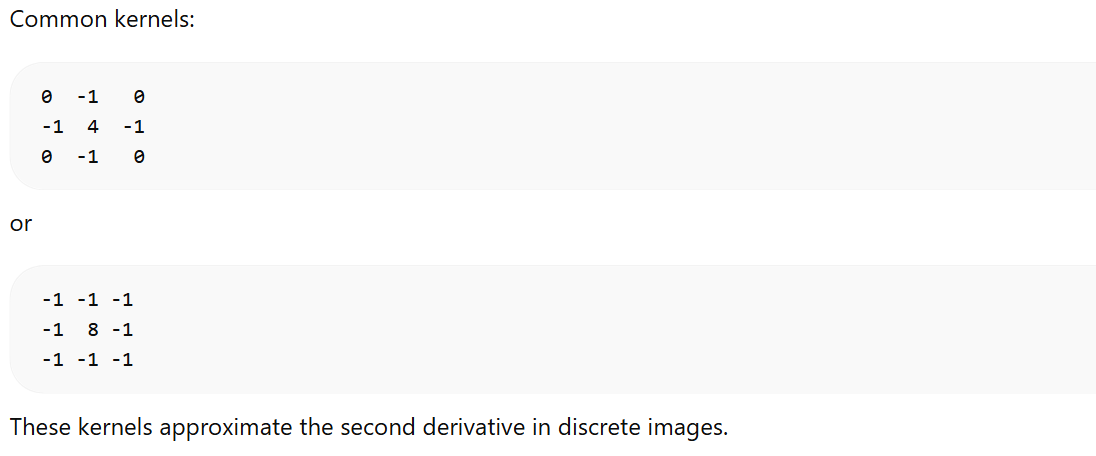
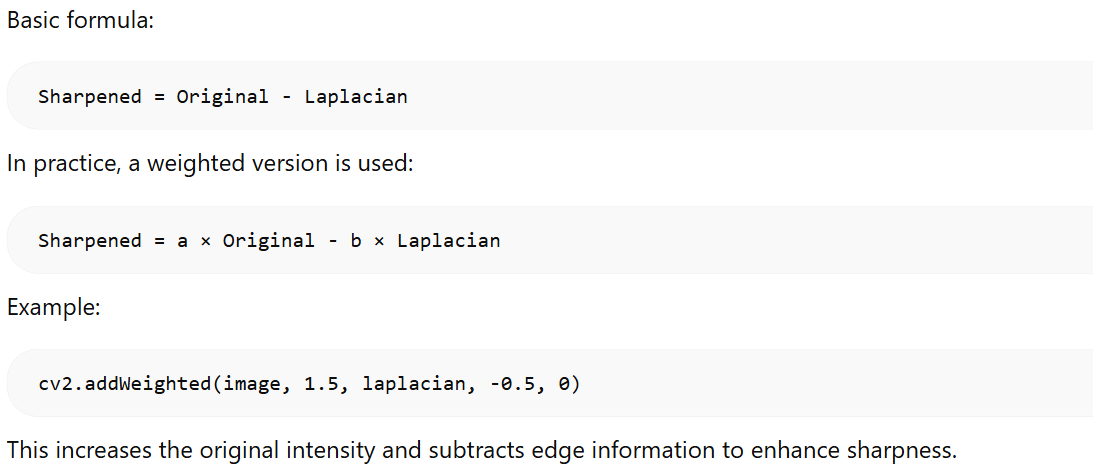
# Why Gaussian Blur is Important
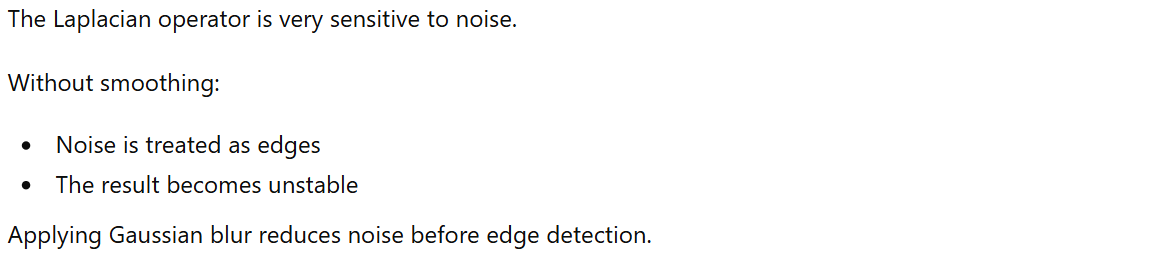

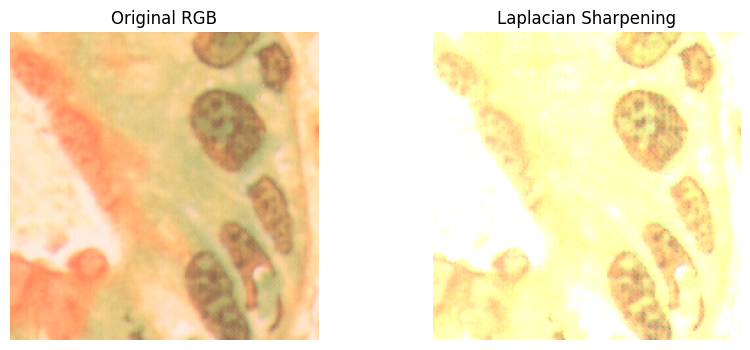

In [20]:
image = cv2.imread('mostBlur.png')
rgbimage = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

laplacian = cv2.Laplacian(rgbimage, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

sharpened = cv2.addWeighted(rgbimage, 1.5, laplacian, -0.5, 0)
# Sharpened = 1.5 × Original - 0.5 × Laplacian

# sharpened = cv2.addWeighted(rgbimage, 1.2, laplacian, -0.2, 0) <-- Mid Sharpen
# sharpened = cv2.addWeighted(rgbimage, 2.0, laplacian, -1.0, 0) <-- Aggressive Sharpen

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sharpened)
plt.title('Laplacian Sharpening')
plt.axis('off')

plt.show()

# With Karnel

## Common Karnel  
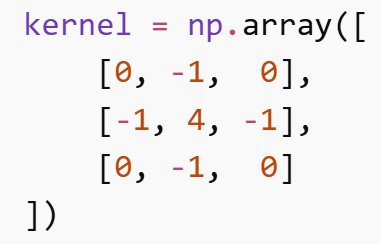

## Strong Karnel  
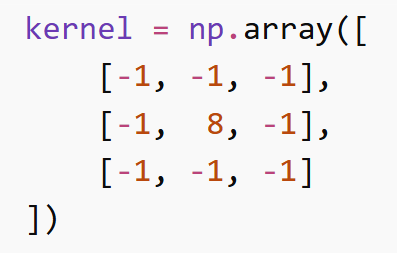

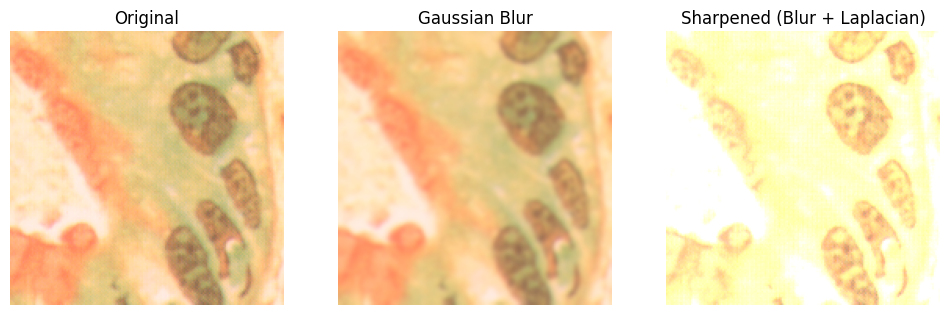

In [24]:
image = cv2.imread('mostBlur.png')
rgbimage = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 1: Gaussian Blur (noise reduction)
blur = cv2.GaussianBlur(rgbimage, (5,5), 0)

# Step 2: Laplacian on blurred image
laplacian = cv2.Laplacian(blur, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

# Step 3: Sharpen
sharpened = cv2.addWeighted(rgbimage, 1.5, laplacian, -0.5, 0)

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(rgbimage)
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(blur)
plt.title('Gaussian Blur')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sharpened)
plt.title('Sharpened (Blur + Laplacian)')
plt.axis('off')

plt.show()

# Unsharp Masking

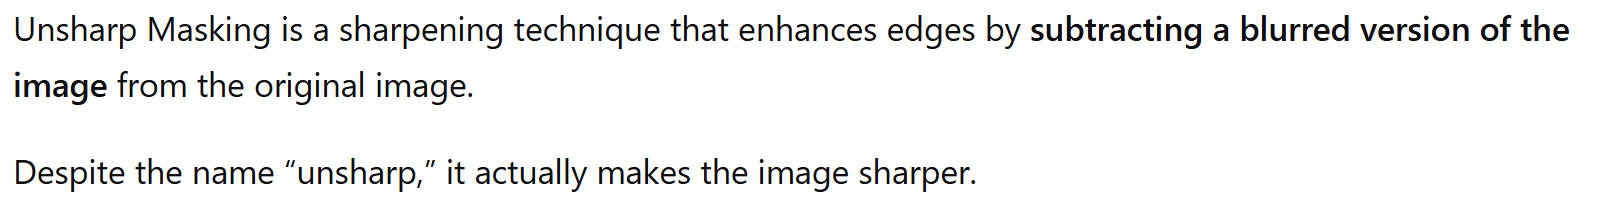
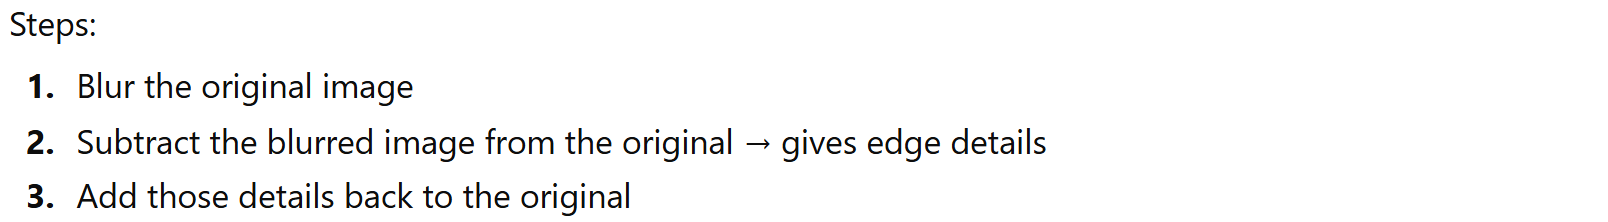
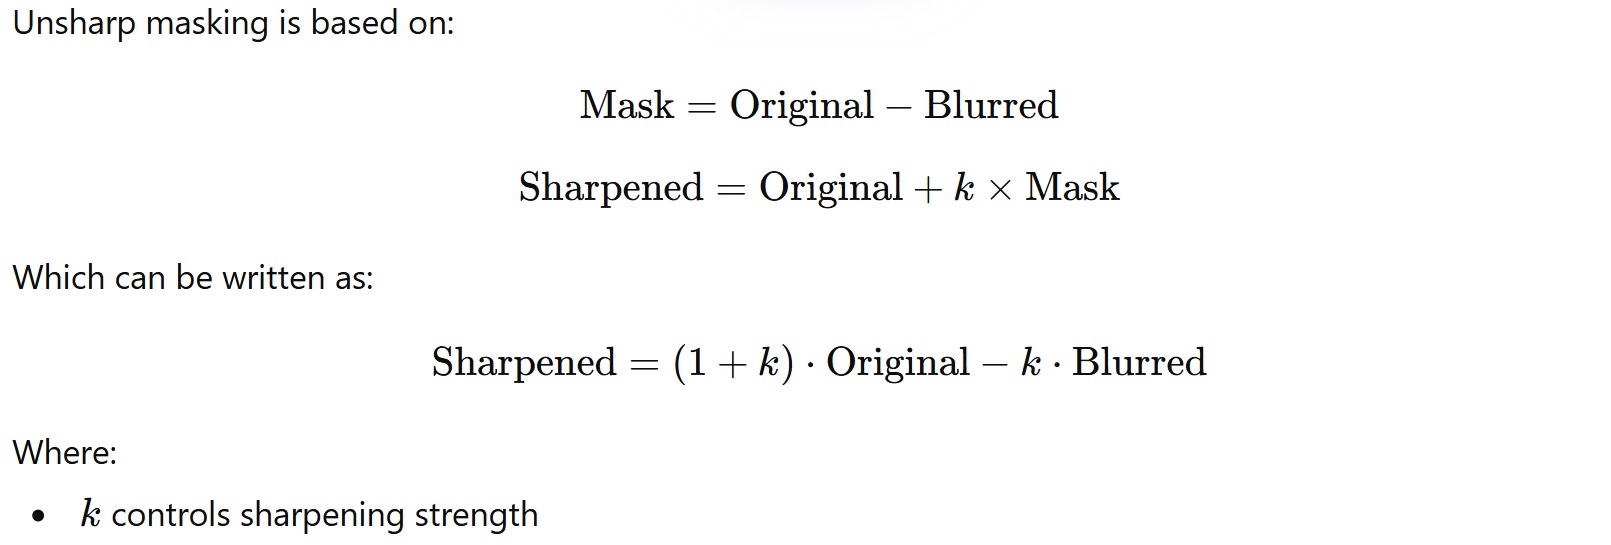
# Intuition
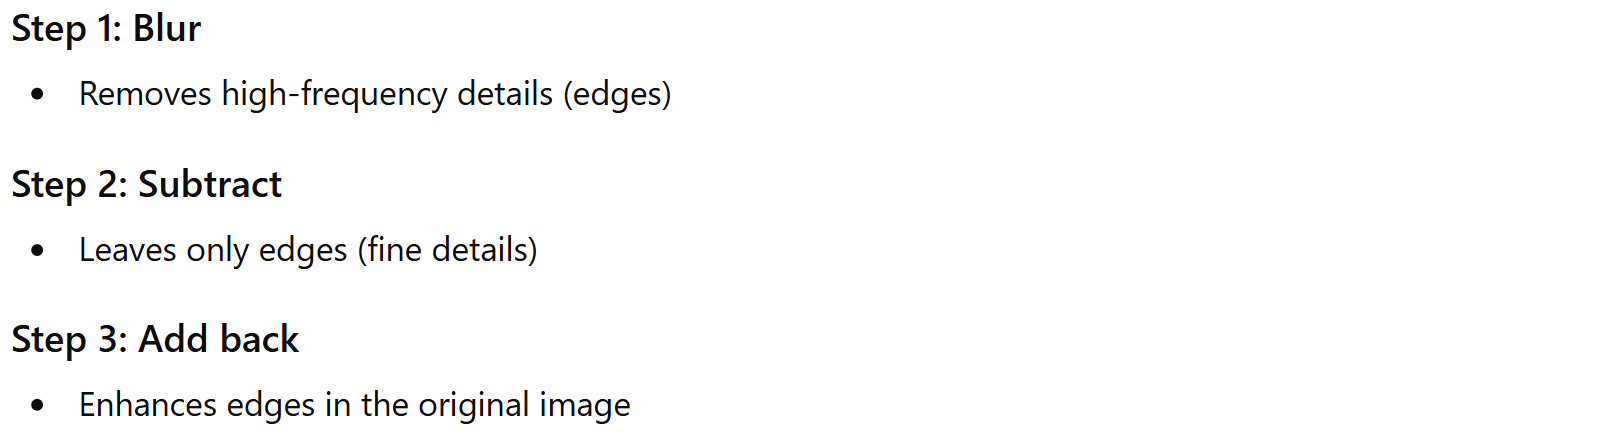

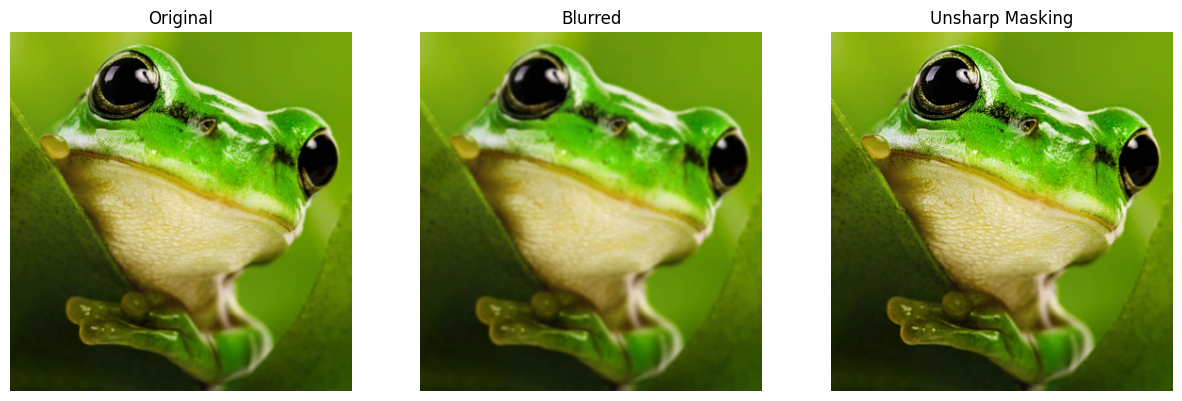

In [28]:
image = cv2.imread('frog.png')
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 1: Blur
blur = cv2.GaussianBlur(rgb, (5,5), 0)

# Step 2: Create mask
mask = cv2.subtract(rgb, blur)

# Step 3: Sharpen
sharpened = cv2.addWeighted(rgb, 1.5, blur, -0.5, 0)

plt.figure(figsize=(15,5))
# Plot
plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(blur)
plt.title('Blurred')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sharpened)
plt.title('Unsharp Masking')
plt.axis('off')

plt.show()

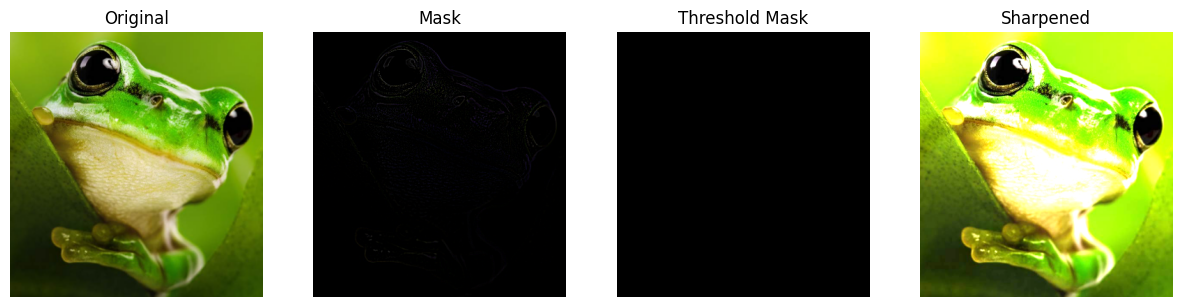

In [54]:
image = cv2.imread('frog.png')
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 1: Blur
blur = cv2.GaussianBlur(rgb, (5,5), 0)

# Step 2: Mask
mask = cv2.subtract(rgb, blur)

# Step 3: Threshold apply
threshold = 150

# Convert mask to grayscale for thresholding
gray_mask = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)

# Create binary mask
_, thresh_mask = cv2.threshold(gray_mask, threshold, 255, cv2.THRESH_BINARY)

# Convert to 3 channel
thresh_mask = cv2.cvtColor(thresh_mask, cv2.COLOR_GRAY2RGB)

# Apply threshold mask
filtered_mask = cv2.bitwise_and(mask, thresh_mask)

# Step 4: Sharpen
sharpened = cv2.addWeighted(rgb, 1.8, filtered_mask, 0.8, 0)

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(mask)
plt.title('Mask')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(filtered_mask)
plt.title('Threshold Mask')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(sharpened)
plt.title('Sharpened')
plt.axis('off')

plt.show()

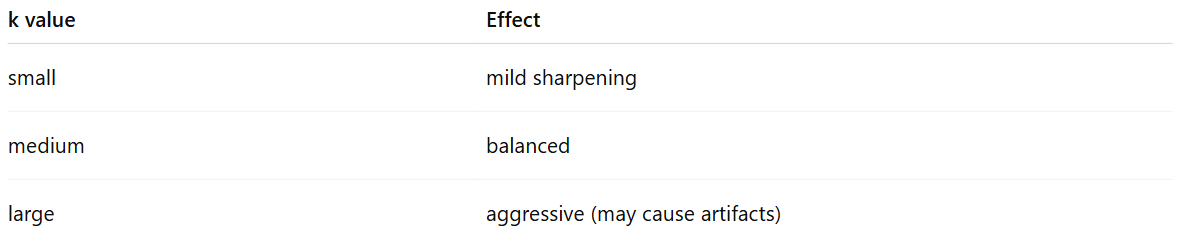